## 1. Load cleaned data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/cleaned/restaurants_cleaned.csv")

df.shape

(1623, 37)

In [3]:
df.head()

,_id,Name,Address,Province_City,Area,Market_Scope,Latitude,Longitude,Avg_Rating,Total_Reviews,...,Has_Curbside,Has_Drive_Through,Phone,Website,Menu_Link,Has_Phone,Has_Website,Has_Menu,Digital_Readiness_Score,URL
0,https://www.google.com/maps/place/Nh%C3%A0+H%C...,Nhà Hàng Ẩm Thực Bờ Sông,"Đường Bờ Sông, Lái Thiêu, Thuận An, Bình Dương...",Bình Dương,Thuận An,Main Market,10.896955,106.695794,3.9,265.0,...,0,0,+84 784 054 898,NaN,NaN,1,0,0,2,https://www.google.com/maps/place/Nh%C3%A0+H%C...
1,https://www.google.com/maps/place/Subin+BBQ+Vi...,Subin BBQ Vincom Dĩ An Buffet Nướng Hàn Quốc,"79 ĐT743B, Khu Phố Thống Nhất 1, Thành Phố, Bì...",Bình Dương,Dĩ An,Main Market,10.908412,106.741475,4.6,461.0,...,0,0,+84 274 6268 608,facebook.com,NaN,1,1,0,2,https://www.google.com/maps/place/Subin+BBQ+Vi...
2,https://www.google.com/maps/place/L%C3%A0ng+%E...,Làng Ẩm Thực 126 - Tiệc trọn gói hoàn hảo tại ...,"1/6 ĐT743B khu phố Bình Đức 1, Thuận An, Bình ...",Bình Dương,Thuận An,Main Market,10.901151,106.713094,4.1,61.0,...,0,0,+84 912 715 126,langamthuc126.com,https://langamthuc126.com/,1,1,1,4,https://www.google.com/maps/place/L%C3%A0ng+%E...
3,https://www.google.com/maps/place/Nh%C3%A0+h%C...,Nhà hàng ẨM THỰC SÂN VƯỜN,"16 Võ Thị Sáu, Đông Hòa, Dĩ An, Bình Dương, Vi...",Bình Dương,Dĩ An,Main Market,10.891235,106.774655,3.7,18.0,...,0,0,+84 902 913 622,NaN,NaN,1,0,0,2,https://www.google.com/maps/place/Nh%C3%A0+h%C...
4,https://www.google.com/maps/place/%E1%BA%A8m+T...,Ẩm Thực Song Phụng 2 I Quán Ăn Sân Vườn Quận 1...,"637/10/49 Tổ 30, Khu Phố 2, Quận 12, Hồ Chí Mi...",HCM,Quận 12,Main Market,10.888727,106.675828,4.3,47.0,...,0,1,+84 965 668 839,amthucsongphung2.com,NaN,1,1,0,3,https://www.google.com/maps/place/%E1%BA%A8m+T...


## 2. Overview KPIs

In [4]:
kpi_summary = {
    "Total Restaurants": len(df),
    "Total Reviews": df["Total_Reviews"].sum(),
    "Average Rating": df["Avg_Rating"].mean(),
    "Median Reviews": df["Total_Reviews"].median(),
    "Website Coverage": df["Has_Website"].mean(),
    "Menu Coverage": df["Has_Menu"].mean(),
    "Delivery Coverage": df["Has_Delivery"].mean()
}

kpi_summary

{'Total Restaurants': 1623,
 'Total Reviews': np.float64(977298.0),
 'Average Rating': np.float64(4.420308641975309),
 'Median Reviews': 196.0,
 'Website Coverage': np.float64(0.44731977818853974),
 'Menu Coverage': np.float64(0.19038817005545286),
 'Delivery Coverage': np.float64(0.6087492298213185)}

The dataset contains 1,625 restaurant records with nearly 1 million customer reviews. Website and menu coverage are still limited, which creates opportunities for digital improvement.

## 3. Market scope analysis

In [5]:
df["Market_Scope"].value_counts()

Market_Scope
Main Market            1474
Outside Main Market     149
Name: count, dtype: int64

In [6]:
df["Province_City"].value_counts()

Province_City
HCM           1359
Bình Dương     115
Đồng Nai        86
Không rõ        56
Long An          6
Tây Ninh         1
Name: count, dtype: int64

Most records are located in the main market, especially HCM and Bình Dương. Records outside the main market are kept for transparency but can be excluded from the main dashboard.

## 4. Area distribution

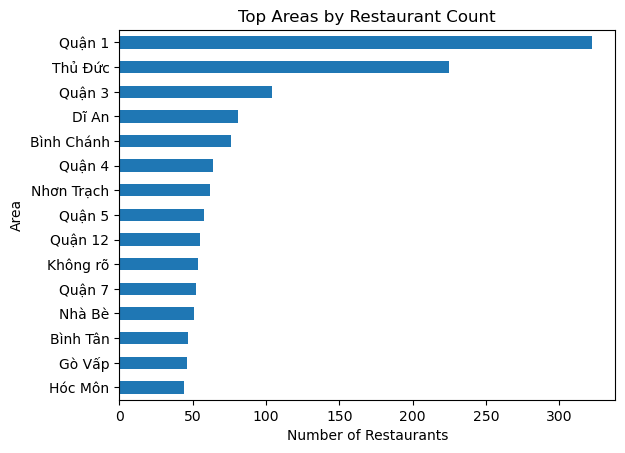

In [8]:
area_summary = (
    df.groupby("Area")
    .agg(
        restaurants=("Name", "count"),
        total_reviews=("Total_Reviews", "sum"),
        avg_rating=("Avg_Rating", "mean"),
        median_reviews=("Total_Reviews", "median")
    )
    .sort_values("restaurants", ascending=False)
)

area_summary.head(20)

area_summary["restaurants"].head(15).sort_values().plot(kind="barh")
plt.title("Top Areas by Restaurant Count")
plt.xlabel("Number of Restaurants")
plt.ylabel("Area")
plt.show()

## 5. Rating vs review reliability

In [9]:
df[["Avg_Rating", "Total_Reviews", "Bayesian_Score"]].describe()

,Avg_Rating,Total_Reviews,Bayesian_Score
count,1620.000000,1620.00000,1620.000000
mean,4.420309,603.27037,4.385108
std,0.365888,1280.80067,0.192499
min,1.800000,1.00000,2.860377
25%,4.100000,31.00000,4.279795
50%,4.400000,196.00000,4.414457
75%,4.700000,664.75000,4.462829
max,5.000000,22395.00000,4.980902


In [10]:
df.sort_values("Avg_Rating", ascending=False)[
    ["Name", "Area", "Avg_Rating", "Total_Reviews"]
].head(20)

,Name,Area,Avg_Rating,Total_Reviews
1569,Salmon Sushi - Cá hồi ngâm tương,Nhà Bè,5.0,13.0
1582,Món Ngon Chuẩn Hàn Cô Hương,Không rõ,5.0,2.0
25,Cafe Trà Sữa,Dĩ An,5.0,2.0
1581,Quán cơm từ thiện 2000đ,Thủ Đức,5.0,1.0
1554,"Quán nấm( bún riêu , cơm)",Biên Hòa,5.0,4.0
1047,Quán Ăn Gia Đình Người Một Nhà,Quận 6,5.0,1.0
28,Quán ăn Dĩ An,Dĩ An,5.0,1.0
1298,Quán Ăn Tường Vy,Quận 7,5.0,1.0
493,Du thuyền Nhà hàng Benthanh Princess,Quận 4,5.0,3200.0
1260,Người Hà Nội Quán,Bến Cát,5.0,2.0


In [11]:
df.sort_values("Bayesian_Score", ascending=False)[
    ["Name", "Area", "Avg_Rating", "Total_Reviews", "Bayesian_Score"]
].head(20)

,Name,Area,Avg_Rating,Total_Reviews,Bayesian_Score
907,Garden in Island by Mars Venus,Quận 7,5.0,5772.0,4.980902
493,Du thuyền Nhà hàng Benthanh Princess,Quận 4,5.0,3200.0,4.966440
200,LONG WANG CityLand Park Hills,Gò Vấp,5.0,1809.0,4.943163
1300,Hoàng's Kitchen,Quận 1,4.9,19063.0,4.895102
1291,Tung's Restaurant - Vietnamese Cuisine & veget...,Quận 1,4.9,10848.0,4.891458
943,Panda Tên Lửa,Bình Tân,4.9,7418.0,4.887611
228,Tiệm Nướng NỌ,Tân Bình,4.9,7148.0,4.887155
494,Uchi Sushi,Quận 4,4.9,6194.0,4.885238
1187,Panda Nguyễn Thị Thập,Quận 7,4.9,6077.0,4.884963
1292,Hai’s Restaurant,Quận 1,4.9,5686.0,4.883963


Raw rating can be misleading because some restaurants have very high ratings but very few reviews. Bayesian Score provides a more reliable ranking by balancing rating and review volume.

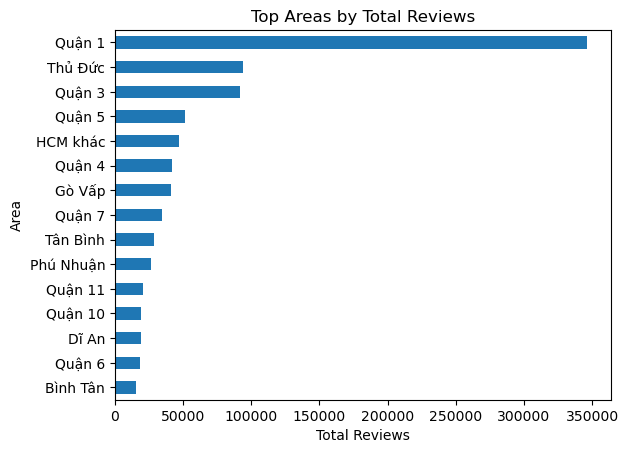

In [21]:
area_reviews = (
    df.groupby("Area")["Total_Reviews"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

area_reviews.sort_values().plot(kind="barh")
plt.title("Top Areas by Total Reviews")
plt.xlabel("Total Reviews")
plt.ylabel("Area")
plt.show()

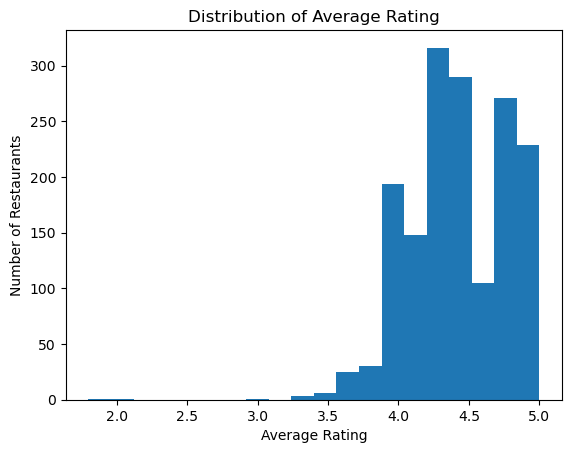

In [22]:
df["Avg_Rating"].plot(kind="hist", bins=20)
plt.title("Distribution of Average Rating")
plt.xlabel("Average Rating")
plt.ylabel("Number of Restaurants")
plt.show()

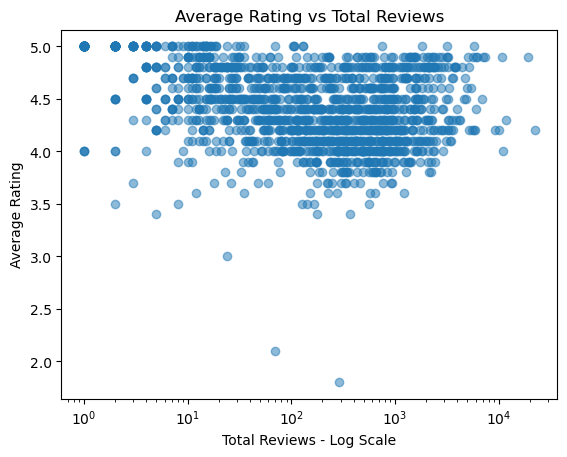

In [23]:
plt.scatter(df["Total_Reviews"], df["Avg_Rating"], alpha=0.5)
plt.xscale("log")
plt.title("Average Rating vs Total Reviews")
plt.xlabel("Total Reviews - Log Scale")
plt.ylabel("Average Rating")
plt.show()

## 6. Price analysis

In [16]:
df["Price_Tier"].value_counts(dropna=False)

price_area = (
    df.groupby(["Area", "Price_Tier"])
    .size()
    .reset_index(name="restaurants")
    .sort_values("restaurants", ascending=False)
)

price_area.head(20)

,Area,Price_Tier,restaurants
49,Quận 1,<=100k,147
45,Quận 1,100-200k,49
91,Thủ Đức,<=100k,45
64,Quận 3,<=100k,43
87,Thủ Đức,100-200k,32
69,Quận 4,<=100k,28
88,Thủ Đức,200-300k,24
72,Quận 5,<=100k,23
46,Quận 1,200-300k,15
60,Quận 3,100-200k,15


Price information is missing for nearly half of the restaurants, so price should be used as a segmentation variable rather than a primary ranking metric.

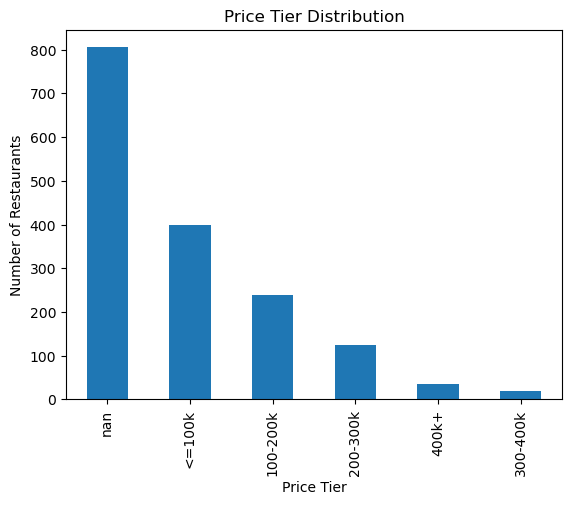

In [24]:
df["Price_Tier"].value_counts(dropna=False).plot(kind="bar")
plt.title("Price Tier Distribution")
plt.xlabel("Price Tier")
plt.ylabel("Number of Restaurants")
plt.show()

## 7. Service option analysis

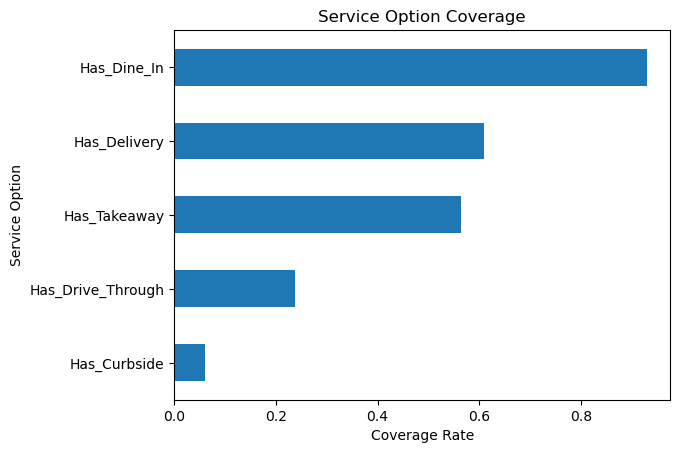

In [17]:
service_summary = df[
    ["Has_Dine_In", "Has_Takeaway", "Has_Delivery", "Has_Curbside", "Has_Drive_Through"]
].mean().sort_values(ascending=False)


service_summary.sort_values().plot(kind="barh")
plt.title("Service Option Coverage")
plt.xlabel("Coverage Rate")
plt.ylabel("Service Option")
plt.show()

## 8. Digital readiness analysis

In [18]:
digital_summary = df[
    ["Has_Website", "Has_Menu", "Has_Phone", "Has_Delivery"]
].mean().sort_values(ascending=False)

digital_summary

Has_Phone       0.850277
Has_Delivery    0.608749
Has_Website     0.447320
Has_Menu        0.190388
dtype: float64

In [19]:
df["Digital_Readiness_Score"].value_counts().sort_index()

Digital_Readiness_Score
0    172
1    329
2    523
3    368
4    231
Name: count, dtype: int64

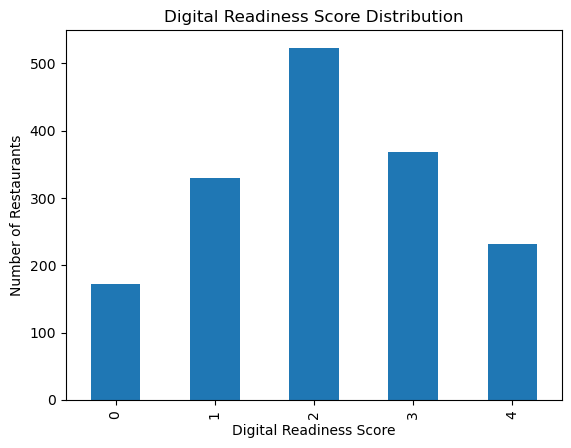

In [25]:
df["Digital_Readiness_Score"].value_counts().sort_index().plot(kind="bar")
plt.title("Digital Readiness Score Distribution")
plt.xlabel("Digital Readiness Score")
plt.ylabel("Number of Restaurants")
plt.show()

Phone coverage is high, but website and menu coverage are much lower. This suggests that many restaurants may still rely on offline or low-digital channels.

## 9. Digital opportunity analysis

In [20]:
df.sort_values("Opportunity_Score", ascending=False)[
    [
        "Name", "Area", "Avg_Rating", "Total_Reviews",
        "Has_Website", "Has_Menu", "Has_Delivery",
        "Digital_Readiness_Score", "Opportunity_Score"
    ]
].head(20)

,Name,Area,Avg_Rating,Total_Reviews,Has_Website,Has_Menu,Has_Delivery,Digital_Readiness_Score,Opportunity_Score
261,Du Miên Garden Cafe,Thủ Đức,4.3,11716.0,0,0,1,2,0.930206
588,HỈN COFFEE,HCM khác,4.8,4479.0,0,0,1,1,0.918959
76,DOOKKI AEON BÌNH DƯƠNG,Dĩ An,4.8,2624.0,0,0,1,2,0.896026
186,Bocaxa beefsteak Gò Vấp,Gò Vấp,4.8,2433.0,0,0,1,2,0.892785
1300,Hoàng's Kitchen,Quận 1,4.9,19063.0,1,1,1,4,0.887089
252,Quán Nhà,Thủ Đức,4.8,2068.0,0,0,1,1,0.885814
340,Soo Kafe Bến Thành,Quận 1,4.7,1922.0,0,0,1,2,0.876675
95,Texas Chicken,Thuận An,4.7,1725.0,0,0,1,2,0.872038
579,Đà Lạt Phố Coffee,Quận 5,4.2,2970.0,0,0,1,2,0.865338
429,Lẩu cá kèo Bà Huyện,Quận 3,4.1,3373.0,0,0,1,2,0.864795
